In [1]:
from pathlib import Path

import prism

from imagematerials.eol import eol_preprocess
from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import (
    EndOfLife,
    GenericMaterials,
    GenericStocks,
    Maintenance,
    MaterialIntensities,
)
from imagematerials.preprocessing import get_preprocessing_data

In [2]:
# Define the complete timeline, including historic tail
# time_start = prep_data["stocks"].coords["Time"].min().values
time_start = 1920
complete_timeline = prism.Timeline(time_start, 2060, 1)
simulation_timeline = prism.Timeline(1970, 2060, 1)

all_output = {}


bld_sector = get_preprocessing_data("buildings", Path("..", "data", "raw"), 
                                        climate_policy_scenario_dir = None, 
                                        circular_economy_scenario_dirs = None) 
vhc_sector = get_preprocessing_data("vehicles", Path("..", "data", "raw"), climate_policy_scenario_dir = None, 
                                        circular_economy_scenario_dirs = None)

# TODO fix this for real in the future
prep_data = vhc_sector.prep_data

# target_materials = [
# "Aluminium", "Brick", "Cement", "Concrete", 
# "Copper", "Glass", "Steel", "Wood"
# ]

# prep_data['battery_materials'] = prep_data['battery_materials'].assign_coords(material = ['Aluminium', 'Co', 'Copper', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb','Plastics', 'Rubber', 'Steel', 'Ti', 'Wood'] )
# prep_data['battery_materials'] = prep_data['battery_materials'].reindex(material=target_materials)
# prep_data['material_fractions'] = prep_data['material_fractions'].assign_coords(material = ['Aluminium', 'Co', 'Copper', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb','Plastics', 'Rubber', 'Steel', 'Ti', 'Wood'] )
# prep_data['material_fractions'] = prep_data['material_fractions'].reindex(material=target_materials)
# prep_data['maintenance_material_fractions'] = prep_data['maintenance_material_fractions'].assign_coords(material = ['Aluminium', 'Co', 'Copper', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb','Plastics', 'Rubber', 'Steel', 'Ti', 'Wood'] )
# prep_data['maintenance_material_fractions'] = prep_data['maintenance_material_fractions'].reindex(material=target_materials)

vhc_sector = Sector('vehicles', prep_data)

# prep_eol = eol_preprocess(Path("..", "data", "raw"), circular_economy_scenario_dirs)
# eol_sector = Sector(name="eol", data = prep_eol)

factory = ModelFactory(
[bld_sector, vhc_sector], complete_timeline
).add(GenericStocks, ["buildings", "vehicles"]
).add(GenericMaterials,  "vehicles"
# ).add(Maintenance, "vehicles"
).add(MaterialIntensities, "buildings",
# ).add(EndOfLife, "eol", input_sources={
# "outflow_by_cohort_materials": ["vehicles", "buildings"],
# "collection": "eol",
# "reuse": "eol",
# "recycling": "eol"}
)
model = factory.finish()

import warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    model.simulate(simulation_timeline)

# all_output[scen_id] = {
#     "inflow_materials": [model.vehicles["inflow_materials"], model.buildings["inflow_materials"]],
#     "reusable_materials": model.eol["reusable_materials"],
#     "recyclable_materials": model.eol["recyclable_materials"]
# }

c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev\Lib\site-packages\xarray\core\indexing.py:1566: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


Mismatch in coordinates with dimension 'Time' with data array 'population' having different coordinates than previously assumed in '['stocks']'.New: [np.int64(1700), np.int64(1701), np.int64(1702), np.int64(1703), np.int64(1704), np.int64(1705), np.int64(1706), np.int64(1707), np.int64(1708), np.int64(1709), np.int64(1710), np.int64(1711), np.int64(1712), np.int64(1713), np.int64(1714), np.int64(1715), np.int64(1716), np.int64(1717), np.int64(1718), np.int64(1719), np.int64(1720), np.int64(1721), np.int64(1722), np.int64(1723), np.int64(1724), np.int64(1725), np.int64(1726), np.int64(1727), np.int64(1728), np.int64(1729), np.int64(1730), np.int64(1731), np.int64(1732), np.int64(1733), np.int64(1734), np.int64(1735), np.int64(1736), np.int64(1737), np.int64(1738), np.int64(1739), np.int64(1740), np.int64(1741), np.int64(1742), np.int64(1743), np.int64(1744), np.int64(1745), np.int64(1746), np.int64(1747), np.int64(1748), np.int64(1749), np.int64(1750), np.int64(1751), np.int64(1752), np

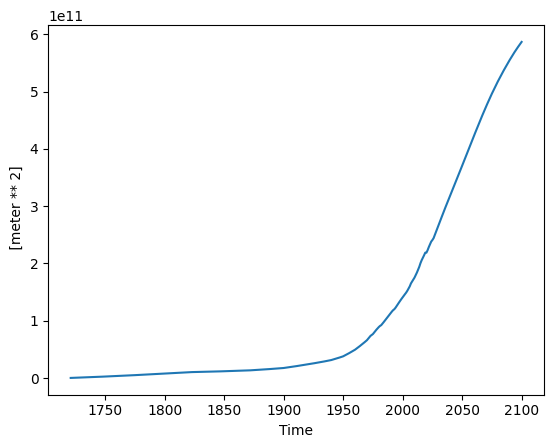

In [3]:
model.buildings.get('stocks').sum(['Type', 'Region']).plot()


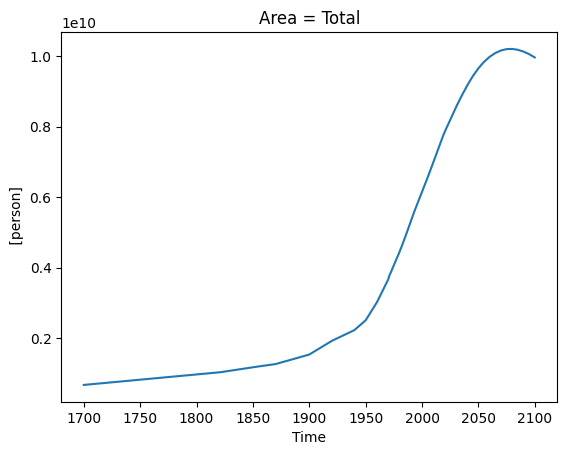

In [4]:
bld_sector.prep_data.get('population').sel(Area = 'Total').sum('Region').plot()

In [5]:
vhc_sector.prep_data.keys()

dict_keys(['lifetimes', 'battery_materials', 'battery_shares', 'material_fractions', 'battery_weights', 'stocks', 'maintenance_material_fractions', 'knowledge_graph', 'weights', 'set_unit_flexible'])

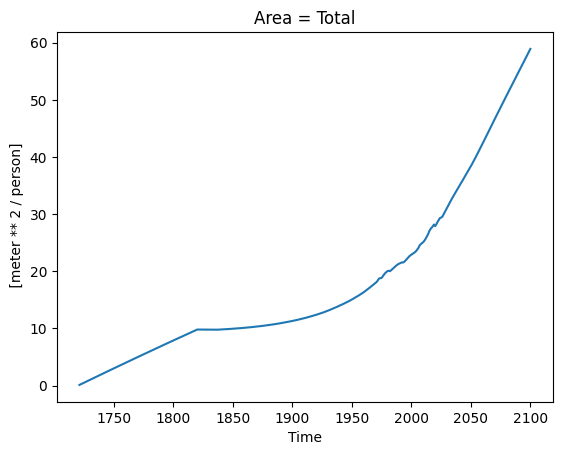

In [6]:
# floorspace per capita
per_cap_floorspace = model.buildings.get('stocks').sum(['Type', 'Region']) / bld_sector.prep_data.get('population').sel(Area = 'Total').sum('Region')
per_cap_floorspace.plot()

In [7]:
stocks = vhc_sector.prep_data.get('stocks')
print(stocks.pint.units)

count


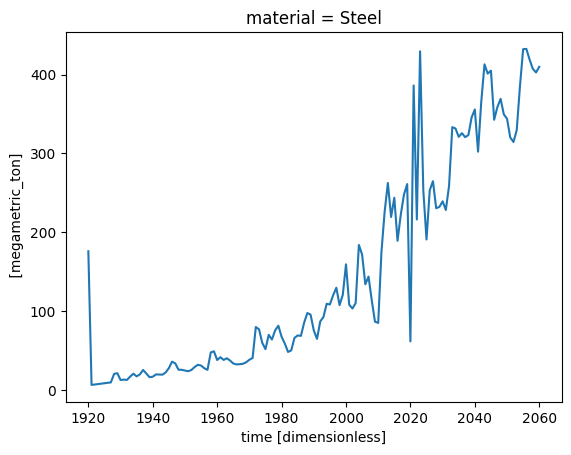

In [8]:
model.vehicles.get('inflow_materials').to_array().sel(material = 'Steel').sum(['Type', 'Region']).pint.to('Mt').plot()

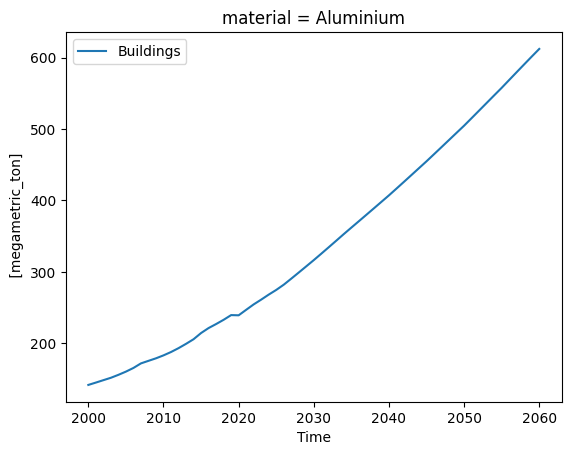

In [62]:
import matplotlib.pyplot as plt
model.buildings.get('stock_by_cohort_materials').sel(material = 'Aluminium').sum(['Type', 'Region']).pint.to('Mt').loc[2000:2060].plot(label = 'Buildings')
#model.vehicles.get('stock_by_cohort_materials').sel(material = 'Aluminium').sum(['Type', 'Region']).pint.to('Mt').loc[2000:2060].plot(label = 'Vehicles')
plt.legend()

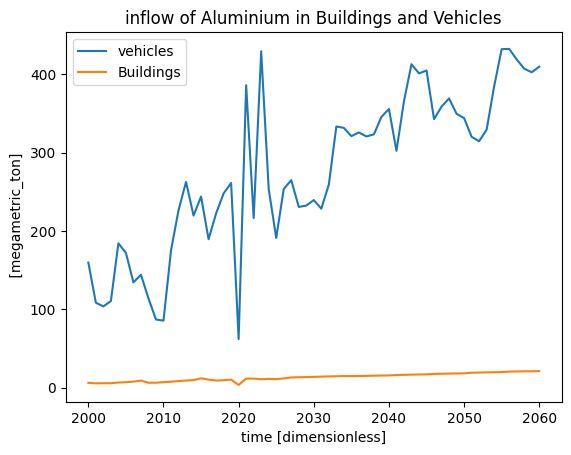

In [75]:
import matplotlib.pyplot as plt

model.vehicles.get('inflow_materials').to_array().sel(material = 'Steel').sum(['Type', 'Region']).pint.to('Mt').loc[2000 : 2060].plot(label = 'vehicles')
model.buildings.get('inflow_materials').to_array().sel(material = 'Aluminium').sum(['Type', 'Region']).pint.to('Mt').loc[2000 : 2060].plot(label = 'Buildings')
plt.title('inflow of Aluminium in Buildings and Vehicles')
plt.legend()

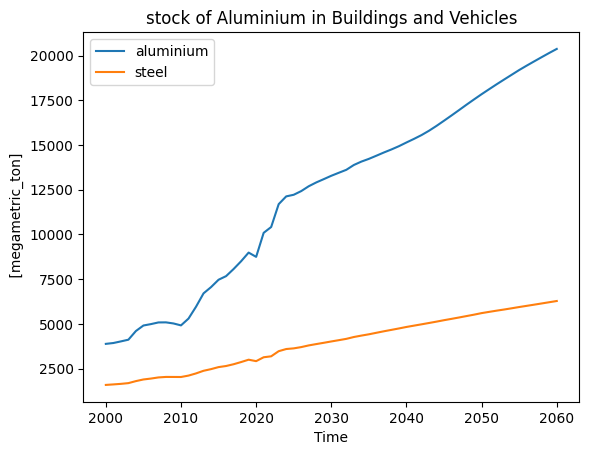

In [76]:

model.vehicles.get('stock_by_cohort_materials').sel(material = 'Aluminium').sum(['Type', 'Region']).loc[2000:2060].pint.to('Mt').plot(label = 'aluminium')
model.vehicles.get('stock_by_cohort_materials').sel(material = 'Steel').sum(['Type', 'Region']).loc[2000:2060].pint.to('Mt').plot(label = 'steel')
plt.title('stock of Aluminium in Buildings and Vehicles')
plt.legend()

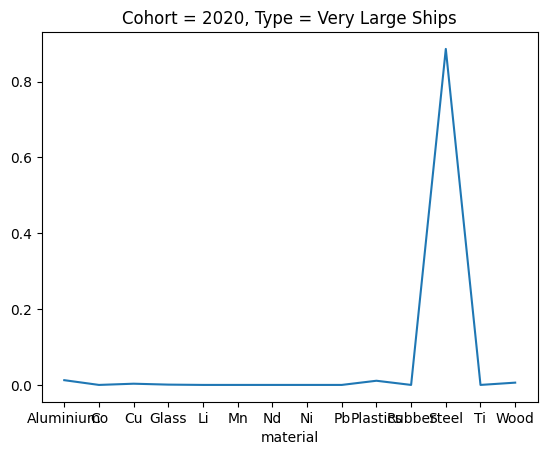

In [53]:
vhc_sector.prep_data.get('material_fractions').sel(Type = 'Very Large Ships').loc[2020].plot()

In [52]:
vhc_sector.prep_data.get('material_fractions')

<xarray.DataArray (Cohort: 294, Type: 47, material: 14)> Size: 2MB
array([[[0.46  , 0.    , 0.    , ..., 0.34  , 0.    , 0.    ],
        [0.68  , 0.    , 0.    , ..., 0.09  , 0.06  , 0.    ],
        [0.0541, 0.    , 0.0015, ..., 0.9445, 0.    , 0.    ],
        ...,
        [0.1898, 0.    , 0.0025, ..., 0.5534, 0.    , 0.    ],
        [0.1898, 0.    , 0.0025, ..., 0.5534, 0.    , 0.    ],
        [0.1898, 0.    , 0.0025, ..., 0.5534, 0.    , 0.    ]],

       [[0.46  , 0.    , 0.    , ..., 0.34  , 0.    , 0.    ],
        [0.68  , 0.    , 0.    , ..., 0.09  , 0.06  , 0.    ],
        [0.0541, 0.    , 0.0015, ..., 0.9445, 0.    , 0.    ],
        ...,
        [0.1898, 0.    , 0.0025, ..., 0.5534, 0.    , 0.    ],
        [0.1898, 0.    , 0.0025, ..., 0.5534, 0.    , 0.    ],
        [0.1898, 0.    , 0.0025, ..., 0.5534, 0.    , 0.    ]],

       [[0.46  , 0.    , 0.    , ..., 0.34  , 0.    , 0.    ],
        [0.68  , 0.    , 0.    , ..., 0.09  , 0.06  , 0.    ],
        [0.0541, 0.    , 0.0015, ..., 0.9445, 0.    , 0.    ],
        ...,
...
        [0.1898, 0.    , 0.0025, ..., 0.5534, 0.    , 0.    ],
        [0.1898, 0.    , 0.0025, ..., 0.5534, 0.    , 0.    ],
        [0.1898, 0.    , 0.0025, ..., 0.5534, 0.    , 0.    ]],

       [[0.46  , 0.    , 0.    , ..., 0.34  , 0.    , 0.    ],
        [0.68  , 0.    , 0.    , ..., 0.09  , 0.06  , 0.    ],
        [0.0541, 0.    , 0.0015, ..., 0.9445, 0.    , 0.    ],
        ...,
        [0.1898, 0.    , 0.0025, ..., 0.5534, 0.    , 0.    ],
        [0.1898, 0.    , 0.0025, ..., 0.5534, 0.    , 0.    ],
        [0.1898, 0.    , 0.0025, ..., 0.5534, 0.    , 0.    ]],

       [[0.46  , 0.    , 0.    , ..., 0.34  , 0.    , 0.    ],
        [0.68  , 0.    , 0.    , ..., 0.09  , 0.06  , 0.    ],
        [0.0541, 0.    , 0.0015, ..., 0.9445, 0.    , 0.    ],
        ...,
        [0.1898, 0.    , 0.0025, ..., 0.5534, 0.    , 0.    ],
        [0.1898, 0.    , 0.0025, ..., 0.5534, 0.    , 0.    ],
        [0.1898, 0.    , 0.0025, ..., 0.5534, 0.    , 0.    ]]],
      shape=(294, 47, 14))
Coordinates:
  * Cohort    (Cohort) int64 2kB 1807 1808 1809 1810 ... 2097 2098 2099 2100
  * Type      (Type) <U35 7kB 'Bikes' ... 'Regular Buses - Trolley'
  * material  (material) <U9 504B 'Aluminium' 'Co' 'Cu' ... 'Steel' 'Ti' 'Wood'